In [14]:
# 퍼셉트론 구현하기
# AND Gate

def AND(x1, x2):
  w1, w2, t = 0.5, 0.5, 0.7
  y = w1 * x1 + w2 * x2
  if y <= t:
    return 0
  elif y > t:
    return 1

print(AND(0, 0))
print(AND(1, 0))
print(AND(0, 1))
print(AND(1, 1))

0
0
0
1


In [15]:
# 가중치와 편향
import numpy as np

def AND(x1, x2):
  x = np.array([x1, x2])
  w = np.array([0.5, 0.5])
  b = -0.7
  y = np.sum(w * x) + b
  if y <= 0:
    return 0
  elif y > 0:
    return 1

print(AND(0, 0))
print(AND(1, 0))
print(AND(0, 1))
print(AND(1, 1))
print()

# NAND Gate
def NAND(x1, x2):
  x = np.array([x1, x2])
  w = np.array([-0.5, 0-0.5])
  b = 0.7
  y = np.sum(w * x) + b
  if y <= 0:
    return 0
  elif y > 0:
    return 1

print(NAND(0, 0))
print(NAND(1, 0))
print(NAND(0, 1))
print(NAND(1, 1))
print()
def OR(x1, x2):
  x = np.array([x1, x2])
  w = np.array([0.5, 0.5])
  b = -0.2
  y = np.sum(x * w) + b
  if y <= 0:
    return 0
  elif y > 0:
    return 1

print(OR(0, 0))
print(OR(1, 0))
print(OR(0, 1))
print(OR(1, 1))

0
0
0
1

1
1
1
0

0
1
1
1


In [16]:
# XOR Gate

def XOR(x1, x2):
  s1 = NAND(x1, x2)
  s2 = OR(x1, x2)
  return AND(s1, s2)


print(XOR(0, 0))
print(XOR(1, 0))
print(XOR(0, 1))
print(XOR(1, 1))

0
1
1
0


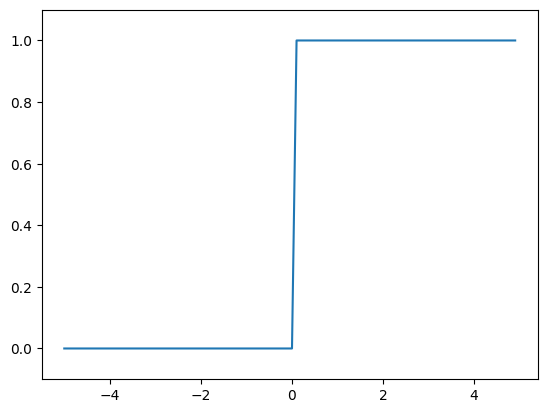

In [17]:
# 계단 함수 구현
def step_function(x):
  y = x > 0 # 0보다 크면 True 작으면 False 로 반환
  return y.astype(np.int64) # True, False 를 1, 0 으로 반환

# 계단 함수 그래프
import matplotlib.pyplot as plt

x = np.arange(-5.0, 5.0, 0.1) # -5.0 ~ 0.5 까지 0.1 간격의 값을 리스트로 생성
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()



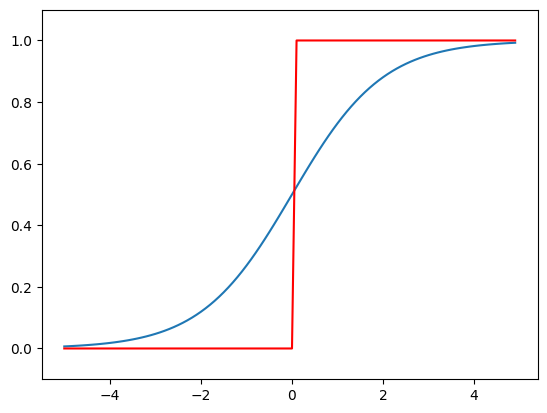

In [18]:
# 시그모이드 함수
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
y1 = step_function(x)
plt.plot(x, y)
plt.plot(x, y1, c='red')
plt.ylim(-0.1, 1.1)
plt.show()

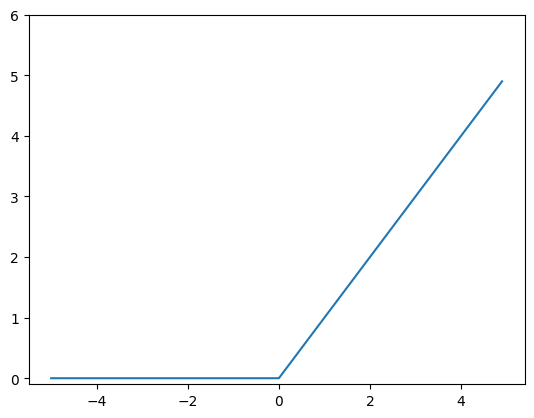

In [ ]:
# ReLU
def ReLU(x):
  return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = ReLU(x)
plt.plot(x, y)
plt.ylim(-0.1, 6.0)
plt.show()

In [ ]:
# 행렬곱
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])

print(W1.shape)
print(B1.shape)
print(X.shape)

A1 = np.dot(X, W1) + B1
print(A1)

# sigmoid 적용
Z1 = sigmoid(A1)
print(Z1)

# 2층 은닉층
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

A2 = np.dot(Z1, W2) + B2
print(A2)
Z2 = sigmoid(A2)
print(Z2)

# 출력층
W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])
A3 = np.dot(Z2, W3) + B3
print(A3)


(2, 3)
(3,)
(2,)
[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]
[0.31682708 0.69627909]


In [ ]:
# 구현 NetWork 정리
def init_network():
  network = {}
  network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
  network['B1'] = np.array([0.1, 0.2, 0.3])
  network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
  network['B2'] = np.array([0.1, 0.2])
  network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
  network['B3'] = np.array([0.1, 0.2])

  return network

def forward(network, x):
  W1, W2, W3 = network['W1'], network['W2'], network['W3']
  B1, B2, B3 = network['B1'], network['B2'], network['B3']

  A1 = np.dot(x, W1) + B1
  Z1 = sigmoid(A1)
  A2 = np.dot(Z1, W2) + B2
  Z2 = sigmoid(A2)
  A3 = np.dot(Z2, W3) + B3
  y = ReLU(A3)

  return y

network = init_network()
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]


In [4]:
# Softmax 함수 와 항등 함수
import numpy as np

a = np.array([0.3,2.9, 4.0])

exp_a = np.exp(a)
print(exp_a)

softmax_a = exp_a / np.sum(exp_a)
print(softmax_a)

sum_a = np.sum(a)
print(a / sum_a)

[ 1.34985881 18.17414537 54.59815003]
[0.01821127 0.24519181 0.73659691]
[0.04166667 0.40277778 0.55555556]


In [6]:
# Sofmax 함수 구현

def softmax(x):
  exp_x = np.exp(x)
  return exp_x / np.sum(exp_x)


# 주의할 점 Overflow 를 조심해야 한다.
def softmax(x):
  c = np.max(x)
  exp_a = np.exp(x - c) # Overflow 방지
  return (exp_a) / np.sum(exp_a)

a = np.array([1010, 1000, 990])
y = softmax(a)
print(y)
print(np.sum(y))

[9.99954600e-01 4.53978686e-05 2.06106005e-09]
1.0


In [25]:
# MNIST 셋 불러오기
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 데이터 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


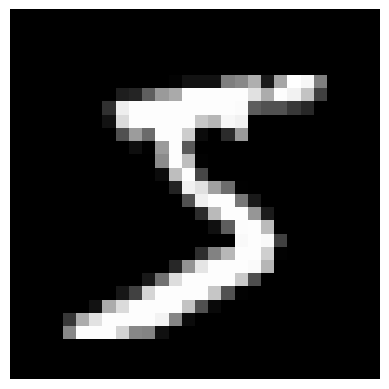

5


In [28]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.axis('off')
plt.show()
print(y_train[0])


In [26]:
# 입력층 뉴런 784개, 출력층 뉴런 10개로 구성
# 28 * 28 = 784 이기 때문에 입력층은 784
# 입력층 -> 은닉층1 -> 은닉층2 -> 출력층
# 은닉층1 뉴런 50개, 은닉층2 뉴런 100개

# 네트워크 구성

def network():
  network = {}
  network["W1"] = np.random.randn(784, 50)
  network["B1"] = np.random.randn(50)
  network["W2"] = np.random.randn(50, 100)
  network["B2"] = np.random.randn(100)
  network['W3'] = np.random.randn(100, 10)
  network["B3"] = np.random.randn(10)
  return network

def predict(network, x):
  W1, W2, W3 = network['W1'], network['W2'], network['W3']
  B1, B2, B3 = network['B1'], network['B2'], network['B3']

  A1 = np.dot(x, W1) + B1
  Z1 = sigmoid(A1)
  A2 = np.dot(Z1, W2) + B2
  Z2 = sigmoid(A2)
  A3 = np.dot(Z2, W3) + B3
  y = softmax(A3)

  return y

network = network()
accuracy_cnt = 0

for i in range(len(x_train)):
  x = x_train[i].flatten()
  p = predict(network, x)
  p = np.argmax(y)
  y = y_train[i]

  if p == y:
    accuracy_cnt += 1

print(accuracy_cnt / len(x_train))


0.09871666666666666


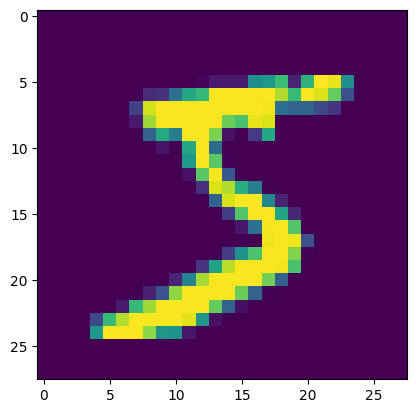

5


In [31]:
x_flatten = x_train[0].flatten()
x_reshape = x_flatten.reshape(28, 28)
plt.imshow(x_reshape)
plt.show()

print(y_train[0])

In [37]:
# 배치를 추가하기
batch_size = 100
accuracy_cnt = 0

for i in range(0, len(x_train), batch_size):
  x_batch = x_train[i:i+batch_size]
  x_batch = x_batch.reshape(batch_size, -1)
  y_batch = predict(network, x_batch)
  p = np.argmax(y_batch, axis=1) # axis=1 열을 기준으로 argmax()
  accuracy_cnt += np.sum(p == y_train[i:i+batch_size])

print(accuracy_cnt / len(x_train))

0.10076666666666667


In [38]:
!pwd

/content


In [46]:
import os

os.chdir('MyDrive/DeepLearning')

In [48]:
!git clone https://github.com/caron2002/DeepLearning.git

Cloning into 'DeepLearning'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [52]:
%cd DeepLear

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
